In [49]:
%matplotlib inline
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pims
import trackpy as tp

import imageio
import cv2
import shutil

from pandas import DataFrame, Series  # for convenience
from PIL import Image

### Set the following variables before running the script:

In [50]:
# Input and output directory, suffix of the input file to process:

input_dir = "E:DATA/Marco_Tjakra-Particle_Tracking_Mucus/240719_data_results_FIJI/"
output_dir = "E:DATA/Marco_Tjakra-Particle_Tracking_Mucus/240719_data_results_TrackMate/"
suffix = ".tif"  # Change this to match your file suffix


# Parameters for the tracking algorithm:

dot_size = 11       # The diameter of the dots (in pixels)
min_mass = 500      # The minimum integrated brightness. Default is 100 for integer images and 1 for float images, but a good value is often much higher.

displacement = 5    # The maximum displacement -> the furthest a particle can travel between two frames
frame_memory = 10   # The memory of disappeared particle for number of frames

trajectory_duration = 10    # The min duration (number of frames) of trajectories that are kept. Trajectories need to exist more (be longer) than e.g. 10 frames

microns_per_pixel = 0.114   # Microns per pixel = 0.1133003
frames_per_second = 1

# Optionally, tweak styles.
mpl.rc('figure',  figsize=(13, 10))
mpl.rc('image', cmap='gray')

In [51]:
@pims.pipeline
def gray(image):
    return image

# Plot each particle as a circle of color on each frame, keeping same color for same particle
color_dict = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#ffffff', '#000000']
# Transform hex to BGR
color_dict = [(int(color[5:7], 16), int(color[3:5], 16), int(color[1:3], 16)) for color in color_dict]


def create_particles_and_trajectories(frames, t2):
    stack = np.zeros((len(frames), frames[0].shape[0], frames[0].shape[1], 3), dtype=np.uint8)
    stack_traj = np.zeros((len(frames), frames[0].shape[0], frames[0].shape[1], 3), dtype=np.uint8)
    trajectories = {}
    
    for i,f in enumerate(frames):
        # Create new rgb frame:
        f = f.astype('float32')
        f[f>700] = 700
        f = (255*f)/f.max()
        f = f.astype('uint8')
        f = cv2.cvtColor(f, cv2.COLOR_GRAY2BGR)
        f_traj = f.copy()
        
        # Get all particles for this frame
        particles = t2[t2['frame'] == i]
        for index, row in particles.iterrows():
            color = color_dict[int(row['particle']) % len(color_dict)]
            x, y = row["x"], row["y"]
            size = np.ceil(row["size"])
            
            # Draw a circle around x,y with color. 
            cv2.circle(f, (int(x), int(y)), int(size)+2, color, 2)
            if row['particle'] not in trajectories.keys():
                trajectories[row['particle']] = []
            trajectories[row['particle']].append((int(x), int(y)))
            
        # Add frame to stack
        stack[i] = f
        
        # Add trajectory to stack_traj
        for particle, trajectory in trajectories.items():
            for j in range(max(0,len(trajectory)-10),len(trajectory)-1):
                cv2.line(f_traj, trajectory[j], trajectory[j+1], color_dict[int(particle) % len(color_dict)], 2)
        stack_traj[i] = f_traj
    return stack, stack_traj    

In [52]:
def save_gif (data_stack, name):
    images = [Image.fromarray(f) for f in data_stack]
    images[0].save(name, format='GIF', save_all=True, append_images=images[1:], optimize=False, duration=150, loop=0)

In [53]:
def process_file(dir_path, filename):
    
    in_file = os.path.join(input_dir, dir_path, filename)
    out_folder = os.path.join(output_dir, dir_path)
    
    # If output folder does not exist, create one
    os.makedirs(out_folder, exist_ok=True)
    basename = os.path.basename(in_file).split(".tif")[0]

    frames = gray(pims.open(in_file))
    print(frames[0])
    
    #--------------------------------------------------
    # Locate_features in frames
    #--------------------------------------------------
    
    # Locate features
    # Pameters of tp.batch are : image, the size of the features (in pixels), min total brightness ("mass"), threshold)
    f = tp.batch(frames, diameter=dot_size, invert=False, minmass=min_mass, processes=1)

    # Link features into particle trajectories
    # Pameters of tp.link are : features, search_range, memory of disappeared particles for number of frames
    t = tp.link(f, search_range=displacement, memory=frame_memory)
    
    # Filter spurious trajectories, seen only for a few frames — are usually spurious and never useful.
    # filter_stubs keeps only trajectories that last for a given number of frames, e.g.50 or 10
    t1 = tp.filter_stubs(t, trajectory_duration)
    
    # Possible to filter features based on 'mass', 'size', 'ecc'
    #e.g: t2 = t1[((t1['mass'] > 50) & (t1['size'] < 2.6) & (t1['ecc'] < 0.2))]
    t2 = t1
    
    #--------------------------------------------------
    # Analyze trajectories
    #--------------------------------------------------
    
    # Compute the drif and subtract it from the overall motion
    d = tp.compute_drift(t2)
    tm = tp.subtract_drift(t2.copy(), d)
    
    # Remove index particle and keep only column particle
    tm = tm.reset_index(drop=True)
    im = tp.imsd(tm, microns_per_pixel, frames_per_second)  # mean squared displacement of individual particle
    em = tp.emsd(tm, microns_per_pixel, frames_per_second)  # ensemble Mean Squared Displacement

    # Performs linear best fit in log space, plots]
    s = tp.utils.fit_powerlaw(em)  

    s.to_csv(f"{output_dir}/n_alpha.csv", mode='a', header=False, index=False)
    tm.to_csv(f"{out_folder}/trackpy_trajectories.csv", index=False)
    
    #--------------------------------------------------
    # Plot and visualise the outputs. Uncomment if needed
    #-------------------------------------------------- 

    # Plot the particles and save the figure
#    fig, ax = plt.subplots()
#    tp.annotate(t2[t2['frame'] == 0], frames[0], plot_style={'markersize': 5})
#    fig.savefig(f"{out_folder}/{basename}_points.png",bbox_inches='tight')
    
    # Plot the trajectories and save the figure
#    fig, ax = plt.subplots()
#    tp.plot_traj(tm, ax=ax)
#    fig.savefig(f"{out_folder}/{basename}_trajectories_plot.png")

    # Create stack of particles and stack of trajectories for saving them as animated gifs   
#    stack, stack_traj = create_particles_and_trajectories(frames, t2)
    
    # Save particles and trajectories as animated gif
#    save_gif(stack, f"{out_folder}/{basename}_particles.gif")
#    save_gif(stack_traj, f"{out_folder}/{basename}_trajectories.gif")
    
    # Save the particles and trajectories to a multi layers tif file
#    imageio.mimwrite(f"{out_folder}/{basename}_particles.tif", stack, format="tif")
#    imageio.mimwrite(f"{out_folder}/{basename}_trajectories.tif", stack_traj, format="tif")

    

Frame 99: 2383 trajectories present.


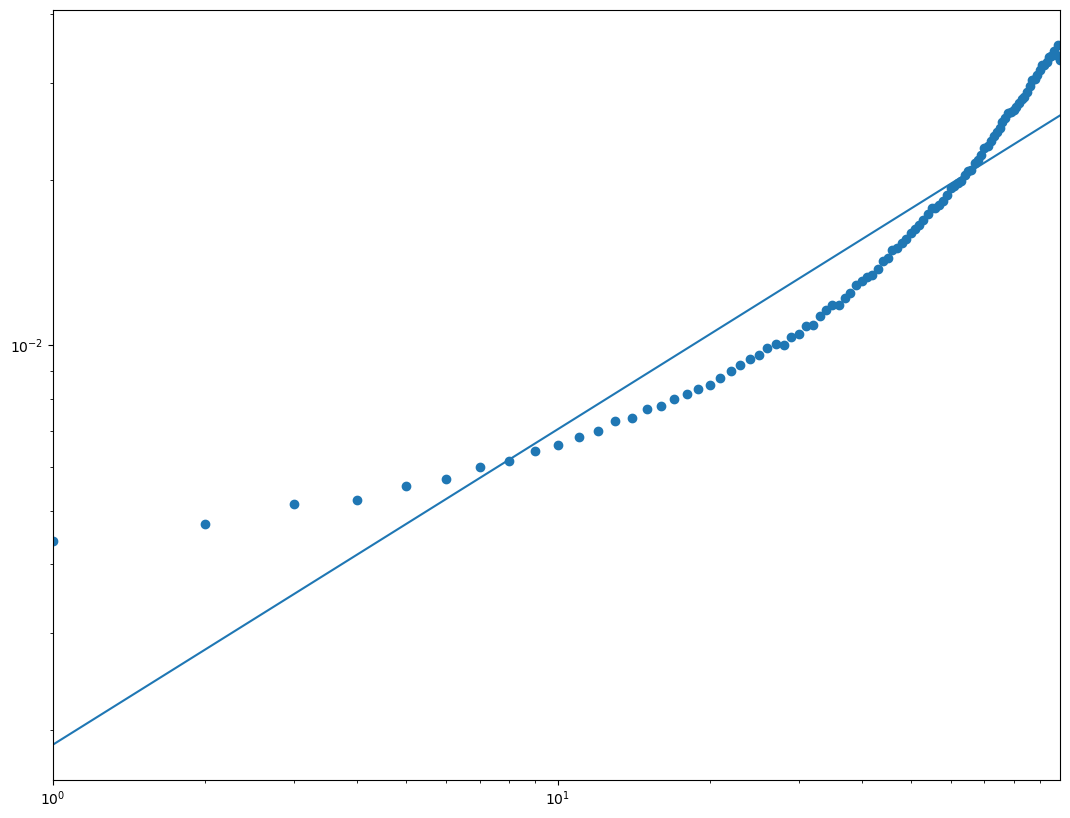

In [54]:
def process_folder_aux():
    process_folder("")

def process_folder(dir_path):
    full_dir = os.path.join(input_dir, dir_path)
    full_out_dir = os.path.join(output_dir, dir_path)
    
    for item in os.listdir(full_dir):
        item_path = os.path.join(full_dir, item)
        out_item_path = os.path.join(full_out_dir, item)
        
        if os.path.isdir(item_path):
            os.makedirs(out_item_path, exist_ok=True)
            process_folder(os.path.join(dir_path, item))
        elif item.endswith(suffix):
            process_file(dir_path, item)


# Run the process
process_folder_aux()